In [1]:
import numpy as np
import pandas as pd
import bnlearn as bn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## **Heart Dataset**

In [ ]:
from KbinsDiscretizer import *

# Load the dataset
heartdata = pd.read_csv('/workspaces/CMP9794-Advanced-Artificial-Intelligence/AAI/data/heart.csv')

### **EDA**

This data set dates from 1988 and consists of four databases: Cleveland, Hungary, Switzerland, and Long Beach V. It contains 76 attributes, including the predicted attribute, but all published experiments refer to using a subset of 14 of them. The "target" field refers to the presence of heart disease in the patient. It is integer valued 0 = no disease and 1 = disease.

1. age
2. sex
3. chest pain type (4 values)
4. resting blood pressure
5. serum cholestoral in mg/dl
6. fasting blood sugar > 120 mg/dl
7. resting electrocardiographic results (values 0,1,2)
8. maximum heart rate achieved
9. exercise induced angina
10. oldpeak = ST depression induced by exercise relative to rest
11. the slope of the peak exercise ST segment
12. number of major vessels (0-3) colored by flourosopy
13. thal: 0 = normal; 1 = fixed defect; 2 = reversable defect


[Kaggle - Heart Disease Dataset, [https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)]

In [ ]:
heartdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
heartdata.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
heart_cont = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
heart_disc = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

print('Continuous columns: ', heart_cont)
print('Discrete columns: ', heart_disc)

Continuous columns:  ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Discrete columns:  ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


### **Pre-Processing**

In [ ]:
# Split the dataset into training and testing sets
train_heart, test_heart = train_test_split(heartdata, test_size=0.2, random_state=7)

# Fit the discretizer on the training set
discretizer_heart, train_dheart = discretize_fit(train_heart, heart_cont, [4,3,3,3,3], transform=True)

# Trasnsform the test set
test_dheart = discretize_transform(test_heart, heart_cont, discretizer_heart)

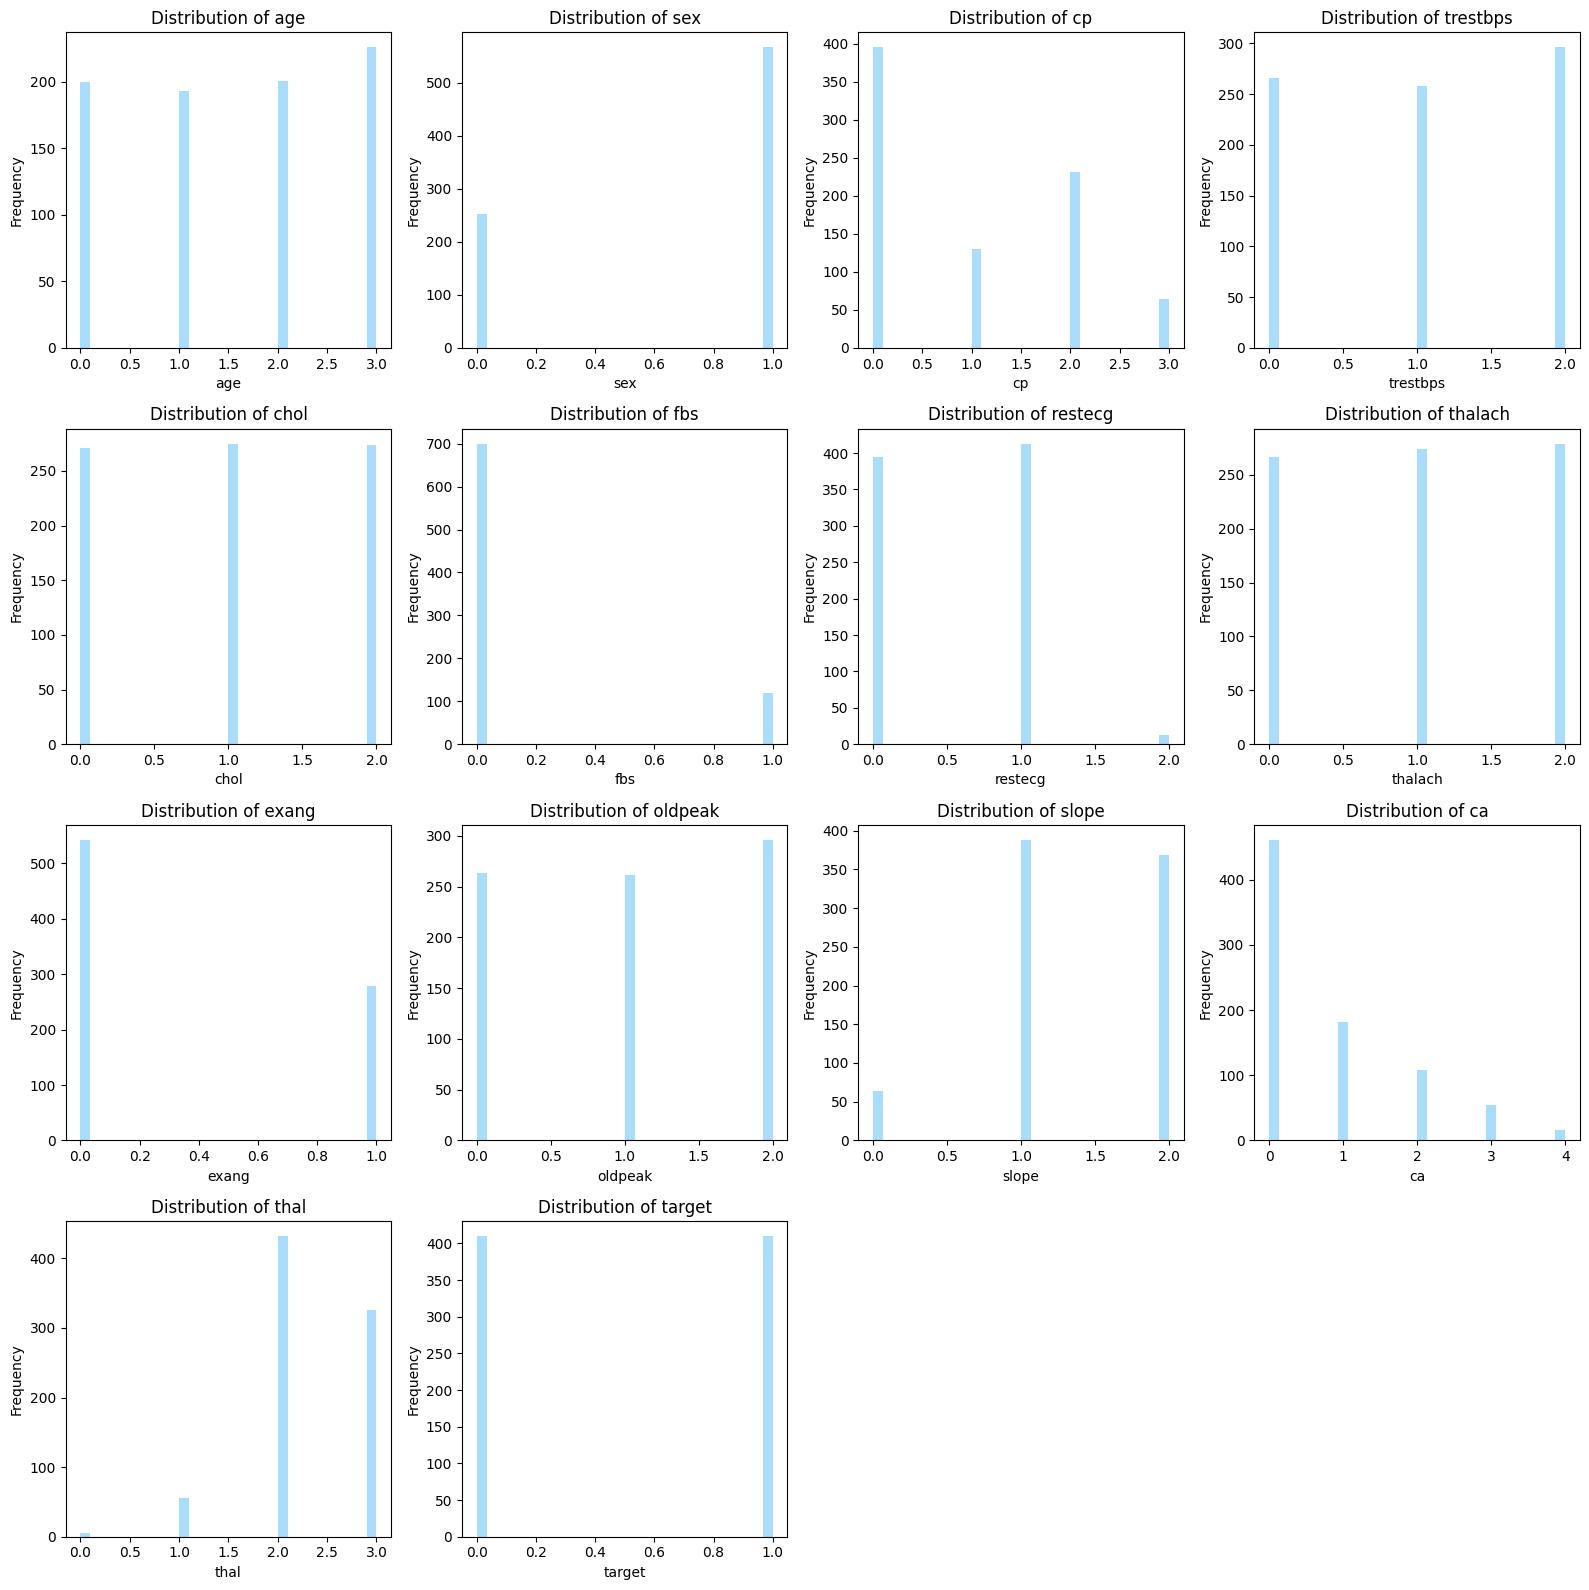

In [7]:
from PlotsFunctions import * 

# Visualize the discretized variables in the train set:
plot_distributions(train_dheart, train_dheart.columns)


### **Structure Learning**

In [8]:
from DiscreteStructureLearning import *

[bnlearn] >Warning: Computing DAG with 14 nodes can take a very long time!
[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
model [hc]={'model': <pgmpy.base.DAG.DAG object at 0x7f81da90fe90>, 'model_edges': [('age', 'trestbps'), ('sex', 'chol'), ('sex', 'target'), ('sex', 'ca'), ('cp', 'exang'), ('trestbps', 'fbs'), ('thalach', 'restecg'), ('exang', 'thalach'), ('oldpeak', 'slope'), ('slope', 'thalach'), ('ca', 'age'), ('thal', 'target'), ('thal', 'sex'), ('target', 'cp'), ('target', 'ca'), ('target', 'oldpeak'), ('target', 'slope'), ('target', 'exang'), ('target', 'chol')], 'adjmat': target      age    sex     cp  trestbps   chol    fbs  restecg  thalach  \
source                                                                    
age       False  False  False      True  False  False    False    False   
sex       False  False  False     False   True  False    False    False   
cp

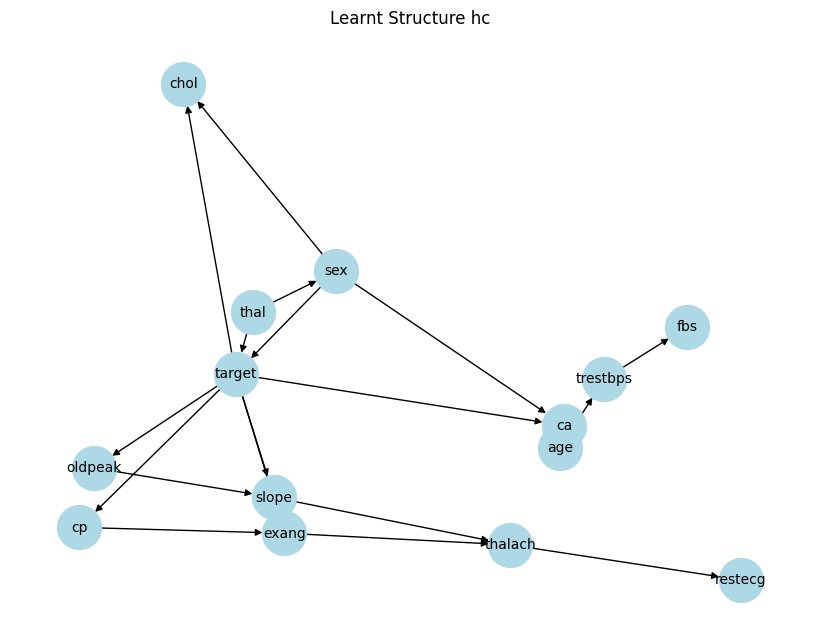

In [15]:
heart_structure = structure_learning(train_dheart, "hc", "bic", 2000000, dataset_name="Heart")

### **Parameter Learning**

In [ ]:
# Learn parameters
param_heart_structure = bn.parameter_learning.fit(heart_structure, train_dheart)

[bnlearn] >Parameter learning> Computing parameters using [bayes]
[bnlearn] >Converting [<class 'pgmpy.base.DAG.DAG'>] to BayesianNetwork model.
[bnlearn] >Converting adjmat to BayesianNetwork.
[bnlearn] >CPD of age:
+----------+---------------------+-----+---------------------+
| ca       | ca(0)               | ... | ca(4)               |
+----------+---------------------+-----+---------------------+
| age(0.0) | 0.3267776096822995  | ... | 0.2824074074074074  |
+----------+---------------------+-----+---------------------+
| age(1.0) | 0.2556732223903177  | ... | 0.2361111111111111  |
+----------+---------------------+-----+---------------------+
| age(2.0) | 0.2102874432677761  | ... | 0.25                |
+----------+---------------------+-----+---------------------+
| age(3.0) | 0.20726172465960666 | ... | 0.23148148148148148 |
+----------+---------------------+-----+---------------------+
[bnlearn] >CPD of trestbps:
+---------------+-----+---------------------+
| age           

## **Fraud Dataset**

In [20]:
# Load the dataset
frauddata = pd.read_csv('/workspaces/CMP9794-Advanced-Artificial-Intelligence/AAI/data/synthetic_fraud_dataset.csv')

### **EDA**

This dataset is designed to help data scientists and machine learning enthusiasts develop robust fraud detection models. It contains realistic synthetic transaction data, including user information, transaction types, risk scores, and more, making it ideal for binary classification tasks with models like XGBoost and LightGBM.

1. Transaction_ID
2. User_ID
3. Transaction_Amount
4. Transaction_Type
5. Timestamp
6. Account_Balance
7. Device_Type
8. Location
9. Merchant_Category
10. IP_Address_Flag
11. Previous_Fraudulent_Activity
12. Daily_Transaction_Count
13. Avg_Transaction_Amount_7d
14. Failed_Transaction_Count_7d
15. Card_Type
16. Card_Age
17. Transaction_Distance
18. Authentication_Method
19. Risk_Score
20. Is_Weekend
21. Fraud_Label

[Kaggle - Fraud Detection Transactions Dataset, https://www.kaggle.com/datasets/samayashar/fraud-detection-transactions-dataset]

In [21]:
frauddata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  F

In [22]:
frauddata.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [ ]:
fraud_cont = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fraud_disc = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

print('Continuous columns: ', fraud_cont)
print('Discrete columns: ', fraud_disc)

### **Pre-Processing**

### **Structure Learning**

### **Parameter Learning**

### **Inference**